# Synthetic Sports Betting Customer Churn Dataset

This notebook generates and validates the synthetic dataset used in the Customer Churn Analytics project.

The dataset simulates customers, sporting events, participants, and betting activity from 2024 through December 30, 2025. The data is synthetic and is intended for analytics and machine learning practice.

### Main tables
- **Customers:** demographic and customer profile information.
- **Participants:** teams and players with popularity, strength, and home-advantage attributes.
- **Events:** sporting events and simulated outcomes.
- **Bets:** customer betting activity linked to events and participants.

### Reproducibility
A fixed random seed is used so that the dataset can be regenerated consistently.


In [1]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

N_CUSTOMERS = 10_000

customers = pd.DataFrame({
    "user_id": [
        f"U{i:06d}" for i in range(1, N_CUSTOMERS + 1)
    ],

    "register_date": pd.to_datetime(
        np.random.choice(
            pd.date_range("2024-01-01", "2025-12-31"),
            N_CUSTOMERS
        )
    ),

    "age": np.random.randint(
        18, 71, N_CUSTOMERS
    ),

    "residence_country": np.random.choice(
        ["Mexico", "Brazil", "Colombia", "Argentina", "Spain"],
        N_CUSTOMERS,
        p=[0.55, 0.16, 0.12, 0.10, 0.07]
    ),

    "payment_method": np.random.choice(
        ["Debit Card", "Credit Card", "Bank Transfer", "Digital Wallet"],
        N_CUSTOMERS,
        p=[0.42, 0.25, 0.20, 0.13]
    ),

    "segment_client": np.random.choice(
        ["Recreational", "Occasional", "High Value", "Seasonal"],
        N_CUSTOMERS,
        p=[0.55, 0.25, 0.10, 0.10]
    )
})

customers.head()

,user_id,register_date,age,residence_country,payment_method,segment_client
0,U000001,2024-04-12,65,Mexico,Debit Card,Recreational
1,U000002,2025-03-11,54,Mexico,Digital Wallet,Occasional
2,U000003,2024-09-27,37,Mexico,Debit Card,High Value
3,U000004,2024-04-16,42,Argentina,Debit Card,Seasonal
4,U000005,2024-03-12,29,Spain,Debit Card,Recreational


In [2]:
customers.shape

(10000, 6)

## 2. Event and participant data

Generate the synthetic sporting events and participant reference data used by the betting activity dataset.


## 2. Event and participant definitions


In [3]:
football_teams = {
    "Liga MX": [
        "América", "Atlas", "Atlético de San Luis", "Cruz Azul", "FC Juárez", "Guadalajara", "León",
        "Mazatlán FC", "Monterrey", "Necaxa", "Pachuca", "Puebla", "Pumas UNAM", "Querétaro", "Santos Laguna",
        "Tigres UANL", "Tijuana", "Toluca"
    ],

    "Premier League": [
        "Arsenal", "Aston Villa", "Bournemouth", "Brentford", "Brighton & Hove Albion", "Chelsea", "Coventry City",
        "Crystal Palace", "Everton", "Fulham", "Hull City", "Ipswich Town", "Leeds United", "Liverpool", "Manchester City",
        "Manchester United", "Newcastle United", "Nottingham Forest", "Sunderland", "Tottenham Hotspur"
    ],

    "LaLiga": [
        "Athletic Club", "Atlético de Madrid", "Barcelona", "Celta de Vigo", "Deportivo Alavés", "Deportivo de la Coruña",
        "Elche", "Espanyol", "Getafe", "Levante", "Málaga", "Osasuna", "Racing de Santander", "Rayo Vallecano", "Real Betis",
        "Real Madrid", "Real Sociedad", "Sevilla", "Valencia", "Villarreal"
    ],

    "Champions League": [
        "AEK Atenas", "Arsenal", "Aston Villa", "Atlético de Madrid", "Barcelona", "Bayern de Múnich", "Bodø/Glimt", "Borussia Dortmund",
        "Calcio Como 1907", "Celtic FC", "Club Brujas", "Fenerbahçe", "Feyenoord", "Galatasaray", "Inter de Milán", "LASK Linz", "Lille",
        "Liverpool", "Manchester City", "Manchester United", "Napoli", "Olympique de Lyon", "Paris Saint-Germain", "Porto", "PSV Eindhoven",
        "Racing de Lens", "Real Betis", "Real Madrid", "Real Sociedad", "Roma", "Sabah FK", "Shajtar Donetsk", "Slavia Praga", "Slovan Bratislava",
        "Sporting CP", "Stuttgart", "VfB Stuttgart", "Viking FK", "Villarreal"
    ]
}

In [4]:
basketball_teams = {
    "NBA":
     ["Atlanta Hawks", "Boston Celtics", "Brooklyn Nets", "Charlotte Hornets",
                    "Chicago Bulls", "Cleveland Cavaliers", "Dallas Mavericks", "Denver Nuggets",
                    "Detroit Pistons", "Golden State Warriors", "Houston Rockets", "Indiana Pacers",
                    "LA Clippers", "Los Angeles Lakers", "Memphis Grizzlies", "Miami Heat", "Milwaukee Bucks",
                    "Minnesota Timberwolves", "New Orleans Pelicans", "New York Knicks", "Oklahoma City Thunder",
                    "Orlando Magic", "Philadelphia 76ers", "Phoenix Suns", "Portland Trail Blazers", "Sacramento Kings",
                    "San Antonio Spurs", "Toronto Raptors", "Utah Jazz", "Washington Wizards"
                    ],


    "EuroLeague":
     ["Anadolu Efes", "ASVEL Villeurbanne", "Barcelona", "Baskonia", "Bayern de Múnich", "Beşiktaş",
                                  "Crvena Zvezda", "Dubai Basketball", "FC Barcelona", "Fenerbahçe", "Hapoel Tel Aviv", "Maccabi Tel Aviv",
                                  "Olimpia Milano", "Olympiacos", "Panathinaikos", "Paris Basketball", "Partizan Belgrado", "Real Madrid",
                                  "Valencia Basket", "Virtus Bologna", "Žalgiris Kaunas"
                                  ]
    }



In [5]:
tennis_players = {
    "ATP Tour": [
        "Alexander Zverev",
        "Carlos Alcaraz",
        "Novak Djokovic",
        "Ben Shelton",
        "Daniil Medvedev",
        "Taylor Fritz",
        "Frances Tiafoe"
    ],
    "WTA Tour": [
        "Aryna Sabalenka",
        "Elena Rybakina",
        "Jessica Pegula",
        "Coco Gauff",
        "Mirra Andreeva",
        "Linda Noskova",
        "Iga Swiatek",
        "Renata Zarazua"
    ]
}


In [6]:
mlb_teams = {
    "American_League": [
        "Baltimore Orioles", "Boston Red Sox", "New York Yankees", "Tampa Bay Rays", "Toronto Blue Jays",
        "Chicago White Sox", "Cleveland Guardians", "Detroit Tigers", "Kansas City Royals", "Minnesota Twins",
        "Houston Astros", "Los Angeles Angels", "Oakland Athletics", "Seattle Mariners", "Texas Rangers"
    ],
    "National_League": [
        "Atlanta Braves", "Miami Marlins", "New York Mets", "Philadelphia Phillies", "Washington Nationals",
        "Chicago Cubs", "Cincinnati Reds", "Milwaukee Brewers", "Pittsburgh Pirates", "St. Louis Cardinals",
        "Arizona Diamondbacks", "Colorado Rockies", "Los Angeles Dodgers", "San Diego Padres", "San Francisco Giants"
    ]
}


In [7]:
sports = {
    "Football": ["Liga MX", "Premier League", "LaLiga", "Champions League"],
    "Basketball": ["NBA", "EuroLeague"],
    "Tennis": ["ATP Tour", "WTA Tour"],
    "Baseball": ["American_League", "National_League"]
}

In [8]:
participants_by_sport = {
    "Football": football_teams,
    "Basketball": basketball_teams,
    "Tennis": tennis_players,
    "Baseball": mlb_teams
}

In [9]:
print(participants_by_sport)

{'Football': {'Liga MX': ['América', 'Atlas', 'Atlético de San Luis', 'Cruz Azul', 'FC Juárez', 'Guadalajara', 'León', 'Mazatlán FC', 'Monterrey', 'Necaxa', 'Pachuca', 'Puebla', 'Pumas UNAM', 'Querétaro', 'Santos Laguna', 'Tigres UANL', 'Tijuana', 'Toluca'], 'Premier League': ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton & Hove Albion', 'Chelsea', 'Coventry City', 'Crystal Palace', 'Everton', 'Fulham', 'Hull City', 'Ipswich Town', 'Leeds United', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Sunderland', 'Tottenham Hotspur'], 'LaLiga': ['Athletic Club', 'Atlético de Madrid', 'Barcelona', 'Celta de Vigo', 'Deportivo Alavés', 'Deportivo de la Coruña', 'Elche', 'Espanyol', 'Getafe', 'Levante', 'Málaga', 'Osasuna', 'Racing de Santander', 'Rayo Vallecano', 'Real Betis', 'Real Madrid', 'Real Sociedad', 'Sevilla', 'Valencia', 'Villarreal'], 'Champions League': ['AEK Atenas', 'Arsenal', 'Aston Villa', 'Atlético de Madrid', 'Ba

In [10]:
print(type(participants_by_sport["Football"]))
print(type(participants_by_sport["Football"]["Liga MX"]))

<class 'dict'>
<class 'list'>


In [11]:
print(type(football_teams))
print(type(basketball_teams))
print(type(tennis_players))
print(type(mlb_teams))

<class 'dict'>
<class 'dict'>
<class 'dict'>
<class 'dict'>


In [12]:
for sport, leagues in participants_by_sport.items():
    print(sport, type(leagues), leagues.keys())

Football <class 'dict'> dict_keys(['Liga MX', 'Premier League', 'LaLiga', 'Champions League'])
Basketball <class 'dict'> dict_keys(['NBA', 'EuroLeague'])
Tennis <class 'dict'> dict_keys(['ATP Tour', 'WTA Tour'])
Baseball <class 'dict'> dict_keys(['American_League', 'National_League'])


In [13]:
print(participants_by_sport["Football"].keys())
print(participants_by_sport["Basketball"].keys())
print(participants_by_sport["Tennis"].keys())
print(participants_by_sport["Baseball"].keys())

dict_keys(['Liga MX', 'Premier League', 'LaLiga', 'Champions League'])
dict_keys(['NBA', 'EuroLeague'])
dict_keys(['ATP Tour', 'WTA Tour'])
dict_keys(['American_League', 'National_League'])


In [14]:
event_rows = []

for sport, leagues in sports.items():
  league = np.random.choice(leagues)
  teams = participants_by_sport[sport][league]
  participants = np.random.choice(teams, 2, replace=False)


In [15]:
n_events=10000

for i in range(n_events):
    sport = np.random.choice(list(sports.keys()))
    competition = np.random.choice(sports[sport])

    teams = participants_by_sport[sport][competition]

    participants = np.random.choice(teams, 2, replace=False)
    #if sport in ["Basketball", "Tennis", "Baseball"]:
     #   result = np.random.choice(["Win", "Loss"])
    #else:
     # result = np.random.choice(["Win", "Loss", "Draw"])
    if sport == "Baseball":
      away = participants[0]
      home = participants[1]
    else:
      home = participants[0]
      away = participants[1]

    event_rows.append({
        "event_id": f"E{i:06d}",
        "event_date": pd.to_datetime(np.random.choice(pd.date_range("2024-01-01", "2025-12-31"))),
        "sport": sport,
        "competition": competition,
        "participants": participants,
        "home_team": home,
        "away_team": away
        #"result": result
        })

In [16]:
events = pd.DataFrame(event_rows)

print(events.head())
print(events.shape)

  event_id event_date       sport      competition  \
0  E000000 2024-05-23    Football          Liga MX   
1  E000001 2024-12-18    Baseball  American_League   
2  E000002 2025-12-05  Basketball       EuroLeague   
3  E000003 2024-04-12      Tennis         WTA Tour   
4  E000004 2025-10-10      Tennis         ATP Tour   

                              participants          home_team  \
0               [Querétaro, Santos Laguna]          Querétaro   
1  [Kansas City Royals, Baltimore Orioles]  Baltimore Orioles   
2                [Panathinaikos, Baskonia]      Panathinaikos   
3          [Linda Noskova, Mirra Andreeva]      Linda Noskova   
4      [Alexander Zverev, Daniil Medvedev]   Alexander Zverev   

            away_team  
0       Santos Laguna  
1  Kansas City Royals  
2            Baskonia  
3      Mirra Andreeva  
4     Daniil Medvedev  
(10000, 7)


In [17]:
print(events.shape)
print(events["sport"].value_counts())
print(events["competition"].value_counts())

(10000, 7)
sport
Football      2553
Basketball    2489
Baseball      2482
Tennis        2476
Name: count, dtype: int64
competition
EuroLeague          1261
American_League     1256
ATP Tour            1246
WTA Tour            1230
NBA                 1228
National_League     1226
Champions League     677
Premier League       663
Liga MX              622
LaLiga               591
Name: count, dtype: int64


## 2.2 Participant attributes


In [18]:
popularity_data = {
    "LaLiga": {
        "Real Madrid": 181000000,
        "Barcelona": 148300000,
        "Atlético de Madrid": 179000000,
        "Sevilla": 4000000,
        "Valencia": 1400000
    },
    "Premier League": {
        "Manchester United": 66100000,
        "Manchester City": 56900000,
        "Liverpool": 48200000,
        "Chelsea": 44400000,
        "Arsenal": 32500000
    },
    "Champions League": {
        "Real Madrid": 181000000,
        "Barcelona": 148300000,
        "Paris Saint-Germain": 67300000,
        "Manchester City": 56900000,
        "Liverpool": 48200000
    },
    "NBA": {
        "Golden State Warriors": 31500000,
        "Los Angeles Lakers": 24600000,
        "Cleveland Cavaliers": 15800000,
        "Chicago Bulls": 10200000,
        "Boston Celtics": 8200000
    },
    "MLB": {
        "New York Yankees": 3400000,
        "Los Angeles Dodgers": 3400000,
        "Boston Red Sox": 2200000,
        "Atlanta Braves": 1700000,
        "Toronto Blue Jays": 1000000
    },
    "Liga MX": {
        "América": 5400000,
        "Guadalajara": 4900000,
        "Tigres UANL": 2700000,
        "Cruz Azul": 2000000,
        "Pumas UNAM": 1200000
    },
    "ATP Tour": {
        "Rafael Nadal": 21300000,
        "Novak Djokovic": 14600000,
        "Carlos Alcaraz": 6300000,
        "Nick Kyrgios": 4100000,
        "Jannik Sinner": 3200000
    },
    "WTA Tour": {
        "Serena Williams": 17300000,
        "Naomi Osaka": 2600000,
        "Coco Gauff": 1800000,
        "Emma Raducanu": 2400000,
        "Aryna Sabalenka": 2200000
    },
    "EuroLeague": {
        "Fenerbahçe Beko": 1700000,
        "Real Madrid Basket": 8900000,
        "FC Barcelona Basket": 750000,
        "Panathinaikos BC": 720000,
        "Partizan Belgrado": 630000
    },
    "American_League": {
        "New York Yankees": 3400000,
        "Boston Red Sox": 2200000,
        "Houston Astros": 1800000,
        "Seattle Mariners": 1100000,
        "Toronto Blue Jays": 1000000
    },
    "National_League": {
        "Los Angeles Dodgers": 3400000,
        "Atlanta Braves": 1700000,
        "Chicago Cubs": 1700000,
        "New York Mets": 1400000,
        "San Francisco Giants": 1400000
    }
}



In [19]:
power_ranking = {
    "LaLiga": {
        "Real Madrid CF": 0.98,
        "FC Barcelona": 0.88,
        "Atlético de Madrid": 0.75,
        "Real Sociedad": 0.62,
        "Athletic Club": 0.48
    },
    "Premier League": {
        "Manchester City": 0.98,
        "Arsenal FC": 0.88,
        "Chelsea FC": 0.75,
        "Liverpool FC": 0.62,
        "Manchester United": 0.48
    },
    "Champions League": {
        "Real Madrid CF": 0.98,
        "Manchester City": 0.88,
        "París Saint-Germain": 0.75,
        "Arsenal FC": 0.62,
        "FC Barcelona": 0.48
    },
    "NBA": {
        "Golden State Warriors": 0.98,
        "New York Knicks": 0.88,
        "Los Angeles Lakers": 0.75,
        "Los Angeles Clippers": 0.62,
        "Chicago Bulls": 0.48
    },
    "MLB": {
        "New York Yankees": 0.98,
        "Los Angeles Dodgers": 0.88,
        "Chicago Cubs": 0.75,
        "Boston Red Sox": 0.62,
        "San Francisco Giants": 0.48
    },
    "Liga MX": {
        "Club América": 0.98,
        "Chivas de Guadalajara": 0.88,
        "Toluca": 0.75,
        "Cruz Azul": 0.62,
        "Tigres UANL": 0.48
    },
    "ATP Tour": {
        "Jannik Sinner": 0.98,
        "Carlos Alcaraz": 0.88,
        "Alexander Zverev": 0.75,
        "Novak Djokovic": 0.62,
        "Daniil Medvedev": 0.48
    },
    "WTA Tour": {
        "Aryna Sabalenka": 0.98,
        "Iga Swiatek": 0.88,
        "Coco Gauff": 0.75,
        "Elena Rybakina": 0.62,
        "Jessica Pegula": 0.48
    },
    "EuroLeague": {
        "Real Madrid Basket": 0.98,
        "Panathinaikos BC": 0.88,
        "Fenerbahçe Beko": 0.75,
        "Olympiacos BC": 0.62,
        "FC Barcelona Basket": 0.48
    },
    "American_League": {
        "New York Yankees": 0.98,
        "Boston Red Sox": 0.88,
        "Houston Astros": 0.75,
        "Toronto Blue Jays": 0.62,
        "Seattle Mariners": 0.48
    },
    "National_League": {
        "Los Angeles Dodgers": 0.98,
        "Chicago Cubs": 0.88,
        "San Francisco Giants": 0.75,
        "Atlanta Braves": 0.62,
        "New York Mets": 0.48
    }
}


In [20]:
rows = []
participant_id = 1

for sport, competitions in participants_by_sport.items():
    for competition in competitions:
        for team in competitions[competition]:

            rows.append({
                "participant_id": participant_id,
                "participant_name": team,
                "sport": sport,
                "competition": competition,
                "popularity_score": popularity_data[competition].get(team),
                "strength_score": power_ranking[competition].get(team),
                "home_advantage": None
            })

            participant_id += 1

participants = pd.DataFrame(rows)

In [21]:
participants.head()

,participant_id,participant_name,sport,competition,popularity_score,strength_score,home_advantage
0,1,América,Football,Liga MX,5400000.0,NaN,None
1,2,Atlas,Football,Liga MX,NaN,NaN,None
2,3,Atlético de San Luis,Football,Liga MX,NaN,NaN,None
3,4,Cruz Azul,Football,Liga MX,2000000.0,0.62,None
4,5,FC Juárez,Football,Liga MX,NaN,NaN,None


In [22]:
participants.isna().sum()

,0
participant_id,0
participant_name,0
sport,0
competition,0
popularity_score,153
strength_score,161
home_advantage,193


In [23]:
participants["sport"].unique()

array(['Football', 'Basketball', 'Tennis', 'Baseball'], dtype=object)

In [24]:
events.head()

,event_id,event_date,sport,competition,participants,home_team,away_team
0,E000000,2024-05-23,Football,Liga MX,"[Querétaro, Santos Laguna]",Querétaro,Santos Laguna
1,E000001,2024-12-18,Baseball,American_League,"[Kansas City Royals, Baltimore Orioles]",Baltimore Orioles,Kansas City Royals
2,E000002,2025-12-05,Basketball,EuroLeague,"[Panathinaikos, Baskonia]",Panathinaikos,Baskonia
3,E000003,2024-04-12,Tennis,WTA Tour,"[Linda Noskova, Mirra Andreeva]",Linda Noskova,Mirra Andreeva
4,E000004,2025-10-10,Tennis,ATP Tour,"[Alexander Zverev, Daniil Medvedev]",Alexander Zverev,Daniil Medvedev


In [25]:
avg_attendance = {
    "LaLiga": {
        # Average home attendance per game (recent season)
        "Real Madrid": 72226,
        "Atlético de Madrid": 63882,
        "Real Betis": 62768,
        "Barcelona": 58547,
        "Athletic Club": 48921
    },
    "Premier League": {
        # Average home attendance per game
        "Manchester United": 73975,
        "Manchester City": 60705,
        "Liverpool": 60415,
        "Tottenham Hotspur": 61025,
        "Arsenal": 60169
    },
    "Champions League": {
        # Estimated average attendance on European matchdays
        "Real Madrid": 75000,
        "Barcelona": 60000,
        "Paris Saint-Germain": 47000,
        "Manchester City": 53000,
        "Liverpool": 60000
    },
    "NBA": {
        # Average home attendance per game
        "Chicago Bulls": 20243,
        "Cleveland Cavaliers": 19432,
        "Boston Celtics": 19156,
        "Los Angeles Lakers": 18854,
        "Golden State Warriors": 18064
    },
    "MLB": {
        # Average home attendance per game
        "Los Angeles Dodgers": 47250,
        "New York Yankees": 41800,
        "Atlanta Braves": 39500,
        "Boston Red Sox": 32400,
        "Toronto Blue Jays": 31200
    },
    "Liga MX": {
        # Espectadores promedio por partido en torneo regular
        "Atlas": 47543,
        "Monterrey": 46593,
        "Guadalajara": 39746,
        "Tigres UANL": 35027,
        "América": 28501
    },
    "EuroLeague": {
        # Average home attendance per game
        "Partizan Belgrado": 19800,
        "Panathinaikos BC": 18500,
        "Real Madrid Basket": 11200,
        "Fenerbahçe Beko": 10400,
        "FC Barcelona Basket": 7200
    },
    "American_League": {
        # Espectadores promedio por partido (Solo Liga Americana de Béisbol)
        "New York Yankees": 41800,
        "Houston Astros": 35200,
        "Toronto Blue Jays": 31200,
        "Boston Red Sox": 32400,
        "Seattle Mariners": 29800
    },
    "National_League": {
        # Espectadores promedio por partido (Solo Liga Nacional de Béisbol)
        "Los Angeles Dodgers": 47250,
        "Atlanta Braves": 39500,
        "Chicago Cubs": 34800,
        "New York Mets": 28500,
        "San Francisco Giants": 31100
    }
}


In [26]:
stadium_capacity = {
    "LaLiga": {
        # Official stadium capacity
        "Real Madrid": 83186,        # Estadio Santiago Bernabéu
        "Atlético de Madrid": 70692,  # Estadio Riyadh Air Metropolitano
        "Real Betis": 60721,         # Estadio Benito Villamarín
        "Barcelona": 105000,         # Spotify Camp Nou (Aforo total tras remodelación)
        "Athletic Club": 53331       # Estadio de San Mamés
    },
    "Premier League": {
        "Manchester United": 74310,  # Old Trafford
        "Tottenham Hotspur": 62850,  # Tottenham Hotspur Stadium
        "Manchester City": 53400,    # Etihad Stadium
        "Liverpool": 61276,          # Anfield (Tras expansión de la tribuna Anfield Road)
        "Arsenal": 60704             # Emirates Stadium
    },
    "Champions League": {
        # Se repiten capacities de sedes principales y se añade el PSG
        "Real Madrid": 83186,
        "Barcelona": 105000,
        "Liverpool": 61276,
        "Manchester City": 53400,
        "Paris Saint-Germain": 47929 # Parc des Princes
    },
    "NBA": {
        # Maximum arena capacity for basketball games
        "Chicago Bulls": 20917,      # United Center
        "Cleveland Cavaliers": 19432, # Rocket Mortgage FieldHouse
        "Boston Celtics": 19156,     # TD Garden
        "Los Angeles Lakers": 19079,  # Crypto.com Arena
        "Golden State Warriors": 18064 # Chase Center
    },
    "MLB": {
        # Capacidad oficial de asientos para béisbol
        "Los Angeles Dodgers": 56000, # Dodger Stadium
        "New York Yankees": 46537,    # Yankee Stadium
        "Atlanta Braves": 41084,     # Truist Park
        "Boston Red Sox": 37755,     # Fenway Park
        "Toronto Blue Jays": 39150    # Rogers Centre (Post-renovaciones)
    },
    "Liga MX": {
        "Atlas": 55110,              # Estadio Jalisco
        "Monterrey": 53500,          # Estadio BBVA
        "Guadalajara": 46355,        # Estadio Akron
        "Tigres UANL": 42000,        # Estadio Universitario (El Volcán)
        "América": 83264             # Estadio Azteca
    },

    "EuroLeague": {
        # Capacidad de los pabellones cubiertos europeos
        "Partizan Belgrado": 20094,   # Stark Arena
        "Panathinaikos BC": 18989,   # OAKA Altion
        "Real Madrid Basket": 17453, # WiZink Center
        "Fenerbahçe Beko": 13059,    # Ülker Sports Arena
        "FC Barcelona Basket": 7585  # Palau Blaugrana
    },
    "American_League": {
        "New York Yankees": 46537,
        "Houston Astros": 41168,     # Minute Maid Park
        "Boston Red Sox": 37755,
        "Toronto Blue Jays": 39150,
        "Seattle Mariners": 47929    # T-Mobile Park
    },
    "National_League": {
        "Los Angeles Dodgers": 56000,
        "Atlanta Braves": 41084,
        "Chicago Cubs": 41649,       # Wrigley Field
        "San Francisco Giants": 41265, # Oracle Park
        "New York Mets": 41922       # Citi Field
    }
}


In [27]:
home_advantage = {}

for competition in stadium_capacity:

    for participant in stadium_capacity[competition]:

        capacity = stadium_capacity[competition][participant]
        avg_data = avg_attendance[competition][participant]

        home_advantage[participant] = (avg_data / capacity) * 0.05

In [28]:
events.head()

,event_id,event_date,sport,competition,participants,home_team,away_team
0,E000000,2024-05-23,Football,Liga MX,"[Querétaro, Santos Laguna]",Querétaro,Santos Laguna
1,E000001,2024-12-18,Baseball,American_League,"[Kansas City Royals, Baltimore Orioles]",Baltimore Orioles,Kansas City Royals
2,E000002,2025-12-05,Basketball,EuroLeague,"[Panathinaikos, Baskonia]",Panathinaikos,Baskonia
3,E000003,2024-04-12,Tennis,WTA Tour,"[Linda Noskova, Mirra Andreeva]",Linda Noskova,Mirra Andreeva
4,E000004,2025-10-10,Tennis,ATP Tour,"[Alexander Zverev, Daniil Medvedev]",Alexander Zverev,Daniil Medvedev


In [29]:
participants.head()

,participant_id,participant_name,sport,competition,popularity_score,strength_score,home_advantage
0,1,América,Football,Liga MX,5400000.0,NaN,None
1,2,Atlas,Football,Liga MX,NaN,NaN,None
2,3,Atlético de San Luis,Football,Liga MX,NaN,NaN,None
3,4,Cruz Azul,Football,Liga MX,2000000.0,0.62,None
4,5,FC Juárez,Football,Liga MX,NaN,NaN,None


In [30]:
for i, row in participants.iterrows():

    name = row["participant_name"]

    if name in home_advantage:
      participants.loc[i, "home_advantage"] = home_advantage[name]
    else:
      participants.loc[i, "home_advantage"] = 0.03

In [31]:
participants.head()

,participant_id,participant_name,sport,competition,popularity_score,strength_score,home_advantage
0,1,América,Football,Liga MX,5400000.0,NaN,0.017115
1,2,Atlas,Football,Liga MX,NaN,NaN,0.043135
2,3,Atlético de San Luis,Football,Liga MX,NaN,NaN,0.03
3,4,Cruz Azul,Football,Liga MX,2000000.0,0.62,0.03
4,5,FC Juárez,Football,Liga MX,NaN,NaN,0.03


In [32]:
participants[["popularity_score", "strength_score", "home_advantage"]].describe()

,popularity_score,strength_score
count,4.000000e+01,32.000000
mean,3.536575e+07,0.718437
std,5.476611e+07,0.181270
min,6.300000e+05,0.480000
25%,1.800000e+06,0.585000
50%,5.850000e+06,0.750000
75%,4.820000e+07,0.880000
max,1.810000e+08,0.980000


In [33]:
participants["strength_score"].describe()

,strength_score
count,32.000000
mean,0.718437
std,0.181270
min,0.480000
25%,0.585000
50%,0.750000
75%,0.880000
max,0.980000


In [34]:
participants["strength_score"] = participants["strength_score"].fillna(
    participants["strength_score"].median()
)

In [35]:
participants["popularity_score"] = participants["popularity_score"].fillna(
    participants["popularity_score"].median()
)

In [36]:
participants.head()

,participant_id,participant_name,sport,competition,popularity_score,strength_score,home_advantage
0,1,América,Football,Liga MX,5400000.0,0.75,0.017115
1,2,Atlas,Football,Liga MX,5850000.0,0.75,0.043135
2,3,Atlético de San Luis,Football,Liga MX,5850000.0,0.75,0.03
3,4,Cruz Azul,Football,Liga MX,2000000.0,0.62,0.03
4,5,FC Juárez,Football,Liga MX,5850000.0,0.75,0.03


In [37]:
participants["competition"].unique()

array(['Liga MX', 'Premier League', 'LaLiga', 'Champions League', 'NBA',
       'EuroLeague', 'ATP Tour', 'WTA Tour', 'American_League',
       'National_League'], dtype=object)

In [38]:
events.head(1)

,event_id,event_date,sport,competition,participants,home_team,away_team
0,E000000,2024-05-23,Football,Liga MX,"[Querétaro, Santos Laguna]",Querétaro,Santos Laguna


In [39]:
home_strength = participants.loc[participants["participant_name"] == events["home_team"].iloc[0], "strength_score"].iloc[0]
away_strength = participants.loc[participants["participant_name"] == events["away_team"].iloc[0], "strength_score"].iloc[0]

In [40]:
for i, row in events.iterrows():
  home = row["home_team"]
  away = row["away_team"]
  home_strength = participants.loc[participants["participant_name"] == home, "strength_score"].iloc[0]
  away_strength = participants.loc[participants["participant_name"] == away, "strength_score"].iloc[0]
  events.loc[i, "home_strength"] = home_strength
  events.loc[i, "away_strength"] = away_strength


In [41]:
events.head()

,event_id,event_date,sport,competition,participants,home_team,away_team,home_strength,away_strength
0,E000000,2024-05-23,Football,Liga MX,"[Querétaro, Santos Laguna]",Querétaro,Santos Laguna,0.75,0.75
1,E000001,2024-12-18,Baseball,American_League,"[Kansas City Royals, Baltimore Orioles]",Baltimore Orioles,Kansas City Royals,0.75,0.75
2,E000002,2025-12-05,Basketball,EuroLeague,"[Panathinaikos, Baskonia]",Panathinaikos,Baskonia,0.75,0.75
3,E000003,2024-04-12,Tennis,WTA Tour,"[Linda Noskova, Mirra Andreeva]",Linda Noskova,Mirra Andreeva,0.75,0.75
4,E000004,2025-10-10,Tennis,ATP Tour,"[Alexander Zverev, Daniil Medvedev]",Alexander Zverev,Daniil Medvedev,0.75,0.48


In [42]:
events[["home_team", "away_team", "home_strength", "away_strength"]].head()

,home_team,away_team,home_strength,away_strength
0,Querétaro,Santos Laguna,0.75,0.75
1,Baltimore Orioles,Kansas City Royals,0.75,0.75
2,Panathinaikos,Baskonia,0.75,0.75
3,Linda Noskova,Mirra Andreeva,0.75,0.75
4,Alexander Zverev,Daniil Medvedev,0.75,0.48


In [43]:
events.isna().sum()
#

,0
event_id,0
event_date,0
sport,0
competition,0
participants,0
home_team,0
away_team,0
home_strength,0
away_strength,0


In [44]:
error = False

for i, row in events.iterrows():
  home_s = row["home_strength"]
  away_s = row["away_strength"]
  home_advantage = participants.loc[participants["participant_name"] == home, "home_advantage"].iloc[0]
  eff_home_strength = row["home_strength"] + home_advantage
  p = eff_home_strength / (eff_home_strength + away_s)
  result = np.random.choice(["Home WIN", "Away WIN"], p=[p, 1-p])
  gap = abs(eff_home_strength - away_s)
  p_draw = max(0, 0.33-0.65*gap)
  remaining = 1 - p_draw

  p_home_final = p * remaining
  p_away_final = (1 - p) * remaining

  if row["sport"] == "Football":
    result = np.random.choice(["Home WIN", "Draw", "Away WIN"], p=[p_home_final, p_draw, p_away_final])
  else:
    result = np.random.choice(["Home WIN", "Away WIN"], p=[p, 1 - p])

  P = p_home_final + p_draw + p_away_final


  events.loc[i, "home_advantage"] = home_advantage
  events.loc[i, "eff_home_strength"] = eff_home_strength
  events.loc[i, "p"] = p
  events.loc[i, "result"] = result

if round(P, 10) != 1:
    print("Error!",1,P)
    error = True
if not error: print("Todo OK!")

Todo OK!


In [45]:
events.head(10)

,event_id,event_date,sport,competition,participants,home_team,away_team,home_strength,away_strength,home_advantage,eff_home_strength,p,result
0,E000000,2024-05-23,Football,Liga MX,"[Querétaro, Santos Laguna]",Querétaro,Santos Laguna,0.75,0.75,0.03,0.78,0.509804,Home WIN
1,E000001,2024-12-18,Baseball,American_League,"[Kansas City Royals, Baltimore Orioles]",Baltimore Orioles,Kansas City Royals,0.75,0.75,0.03,0.78,0.509804,Home WIN
2,E000002,2025-12-05,Basketball,EuroLeague,"[Panathinaikos, Baskonia]",Panathinaikos,Baskonia,0.75,0.75,0.03,0.78,0.509804,Home WIN
3,E000003,2024-04-12,Tennis,WTA Tour,"[Linda Noskova, Mirra Andreeva]",Linda Noskova,Mirra Andreeva,0.75,0.75,0.03,0.78,0.509804,Home WIN
4,E000004,2025-10-10,Tennis,ATP Tour,"[Alexander Zverev, Daniil Medvedev]",Alexander Zverev,Daniil Medvedev,0.75,0.48,0.03,0.78,0.619048,Home WIN
5,E000005,2024-04-30,Basketball,EuroLeague,"[Hapoel Tel Aviv, Olimpia Milano]",Hapoel Tel Aviv,Olimpia Milano,0.75,0.75,0.03,0.78,0.509804,Home WIN
6,E000006,2024-05-12,Football,Liga MX,"[León, Pachuca]",León,Pachuca,0.75,0.75,0.03,0.78,0.509804,Draw
7,E000007,2025-11-24,Basketball,NBA,"[San Antonio Spurs, Brooklyn Nets]",San Antonio Spurs,Brooklyn Nets,0.75,0.75,0.03,0.78,0.509804,Home WIN
8,E000008,2024-07-12,Baseball,American_League,"[Los Angeles Angels, Toronto Blue Jays]",Toronto Blue Jays,Los Angeles Angels,0.62,0.75,0.03,0.65,0.464286,Away WIN
9,E000009,2024-02-04,Tennis,ATP Tour,"[Carlos Alcaraz, Taylor Fritz]",Carlos Alcaraz,Taylor Fritz,0.88,0.75,0.03,0.91,0.548193,Away WIN


## 3. Customer betting activity

Generate betting activity by combining customer behavior, competition preferences, event outcomes, selections, amounts, and returns.


In [46]:
customers.columns

Index(['user_id', 'register_date', 'age', 'residence_country',
       'payment_method', 'segment_client'],
      dtype='object')

## 3. Generate customer activity


In [47]:
end_date = pd.Timestamp("2025-12-30")

customers["active_days"] = (end_date - customers["register_date"]).dt.days

In [48]:
betting_range = {
    "Recreational":(20, 40),
    "Occasional":(70, 130),
    "High Value":(400, 600),
    "Seasonal":(200, 400)
}

In [49]:
customers["annual_bets"] = customers["segment_client"].apply(lambda x:np.random.randint(
    betting_range[x][0],
    betting_range[x][1] + 1))

In [50]:
customers["n_bets"] = (customers["annual_bets"]*customers["active_days"]/365).round().astype(int)

In [51]:
customers.head()

,user_id,register_date,age,residence_country,payment_method,segment_client,active_days,annual_bets,n_bets
0,U000001,2024-04-12,65,Mexico,Debit Card,Recreational,627,34,58
1,U000002,2025-03-11,54,Mexico,Digital Wallet,Occasional,294,97,78
2,U000003,2024-09-27,37,Mexico,Debit Card,High Value,459,417,524
3,U000004,2024-04-16,42,Argentina,Debit Card,Seasonal,623,325,555
4,U000005,2024-03-12,29,Spain,Debit Card,Recreational,658,39,70


In [52]:
customers[[
    "segment_client",
    "active_days",
    "annual_bets",
    "n_bets"
]].head()

,segment_client,active_days,annual_bets,n_bets
0,Recreational,627,34,58
1,Occasional,294,97,78
2,High Value,459,417,524
3,Seasonal,623,325,555
4,Recreational,658,39,70


In [53]:
def generate_date(start_date, n_bets):
  dates = pd.date_range(start=start_date, end = "2025-12-30")

  return np.random.choice(dates, size=n_bets, replace=True)

In [54]:
customers["betting_dates"] = customers.apply(
    lambda row:generate_date(row["register_date"], row["n_bets"]),
    axis=1
)

In [55]:
bets = customers[["user_id", "betting_dates"]].explode("betting_dates").reset_index(drop=True)

bets = bets.rename(columns={"betting_dates":"placement_date"})

In [56]:
bets.head(5)

,user_id,placement_date
0,U000001,2025-06-24
1,U000001,2024-08-30
2,U000001,2024-05-26
3,U000001,2024-07-07
4,U000001,2024-12-13


In [57]:
bets.shape

(1197445, 2)

In [58]:
customers.groupby("segment_client")["n_bets"].agg(["count", "mean", "min", "max", "sum"])


,count,mean,min,max,sum
segment_client,,,,,
High Value,938,503.088486,0,1154,471897
Occasional,2431,97.772110,0,257,237684
Recreational,5566,29.919511,0,80,166532
Seasonal,1065,301.644131,1,779,321251


In [59]:
customers.columns

Index(['user_id', 'register_date', 'age', 'residence_country',
       'payment_method', 'segment_client', 'active_days', 'annual_bets',
       'n_bets', 'betting_dates'],
      dtype='object')

In [60]:
customers['residence_country'].unique()

array(['Mexico', 'Argentina', 'Spain', 'Brazil', 'Colombia'], dtype=object)

In [61]:
events['competition'].unique()

array([np.str_('Liga MX'), np.str_('American_League'),
       np.str_('EuroLeague'), np.str_('WTA Tour'), np.str_('ATP Tour'),
       np.str_('NBA'), np.str_('National_League'),
       np.str_('Premier League'), np.str_('LaLiga'),
       np.str_('Champions League')], dtype=object)

## 3.2 Competition preferences


In [62]:
betting_preferences = {
    "Mexico": {
        "Liga MX": 0.45,
        "Premier League": 0.12,
        "LaLiga": 0.18,
        "Champions League": 0.15,
        "NBA": 0.04,
        "ATP Tour": 0.02,
        "WTA Tour": 0.01,
        "EuroLeague": 0.00,
        "American_League": 0.02,
        "National_League": 0.01
    },

    "Argentina": {
        "Liga MX": 0.01,
        "Premier League": 0.28,
        "LaLiga": 0.25,
        "Champions League": 0.30,
        "NBA": 0.05,
        "ATP Tour": 0.08,
        "WTA Tour": 0.02,
        "EuroLeague": 0.01,
        "American_League": 0.00,
        "National_League": 0.00
    },

    "Spain": {
        "Liga MX": 0.01,
        "Premier League": 0.15,
        "LaLiga": 0.50,
        "Champions League": 0.25,
        "NBA": 0.03,
        "ATP Tour": 0.04,
        "WTA Tour": 0.01,
        "EuroLeague": 0.01,
        "American_League": 0.00,
        "National_League": 0.00
    },

    "Brazil": {
        "Liga MX": 0.01,
        "Premier League": 0.35,
        "LaLiga": 0.20,
        "Champions League": 0.35,
        "NBA": 0.04,
        "ATP Tour": 0.02,
        "WTA Tour": 0.01,
        "EuroLeague": 0.00,
        "American_League": 0.01,
        "National_League": 0.01
    },

    "Colombia": {
        "Liga MX": 0.02,
        "Premier League": 0.28,
        "LaLiga": 0.32,
        "Champions League": 0.30,
        "NBA": 0.03,
        "ATP Tour": 0.02,
        "WTA Tour": 0.01,
        "EuroLeague": 0.01,
        "American_League": 0.01,
        "National_League": 0.00
    }
}

In [63]:
for country, preference in betting_preferences.items():
  print(country, sum(preference.values()))

Mexico 1.0
Argentina 1.0
Spain 1.0
Brazil 1.0
Colombia 1.0


In [64]:
bets = bets.merge(customers[["user_id", "residence_country"]], on="user_id", how='left')

In [65]:
bets.head()

,user_id,placement_date,residence_country
0,U000001,2025-06-24,Mexico
1,U000001,2024-08-30,Mexico
2,U000001,2024-05-26,Mexico
3,U000001,2024-07-07,Mexico
4,U000001,2024-12-13,Mexico


In [66]:
bets['residence_country'].unique()

array(['Mexico', 'Argentina', 'Spain', 'Brazil', 'Colombia'], dtype=object)

In [67]:
bets["competition"] = None

for country, preference in betting_preferences.items():
  mask = bets["residence_country"] == country
  competitions = list(preference.keys())
  weights = list(preference.values())

  bets.loc[mask, "competition"] = np.random.choice(competitions, size=mask.sum(), p=weights)

In [68]:
bets.isna().sum()

,0
user_id,0
placement_date,81
residence_country,0
competition,0


In [69]:
bets[bets["placement_date"].isna()]["user_id"].nunique()

81

In [70]:
bets = bets.dropna(subset=["placement_date"]).reset_index(drop=True)

In [71]:
bets['placement_date'].isna().sum()

np.int64(0)

In [72]:
pd.crosstab(
    bets["residence_country"],
    bets["competition"],
    normalize="index"
).round(3)

competition,ATP Tour,American_League,Champions League,EuroLeague,LaLiga,Liga MX,NBA,National_League,Premier League,WTA Tour
residence_country,,,,,,,,,,
Argentina,0.08,0.00,0.300,0.01,0.252,0.01,0.049,0.00,0.280,0.02
Brazil,0.02,0.01,0.351,0.00,0.200,0.01,0.040,0.01,0.350,0.01
Colombia,0.02,0.01,0.301,0.01,0.320,0.02,0.030,0.00,0.280,0.01
Mexico,0.02,0.02,0.150,0.00,0.180,0.45,0.040,0.01,0.120,0.01
Spain,0.04,0.00,0.253,0.01,0.499,0.01,0.030,0.00,0.149,0.01


In [73]:
bets_test = bets.head(1000).copy()

bets_test = bets_test.sort_values('placement_date')

events_sorted = events.sort_values('event_date')

## 3.3 Match bets to sporting events


In [74]:
bets_test = pd.merge_asof(
    bets_test,
    events_sorted[[
        "event_id",
        "event_date",
        "competition"
    ]],
    left_on="placement_date",
    right_on="event_date",
    by="competition",
    direction="forward"
)

In [75]:
bets_test[[
    "placement_date",
    "competition",
    "event_id",
    "event_date"
]].head(20)

,placement_date,competition,event_id,event_date
0,2024-04-16,Premier League,E003788,2024-04-17
1,2024-04-18,LaLiga,E005554,2024-04-18
2,2024-04-19,Premier League,E005856,2024-04-19
3,2024-04-20,Champions League,E005547,2024-04-21
4,2024-04-22,Champions League,E001243,2024-04-24
5,2024-04-24,Champions League,E001243,2024-04-24
6,2024-04-25,LaLiga,E008839,2024-04-25
7,2024-04-25,LaLiga,E008839,2024-04-25
8,2024-04-27,Premier League,E009498,2024-04-27
9,2024-04-29,Liga MX,E003282,2024-04-30


In [76]:
bets_test["event_id"].isna().sum()

np.int64(0)

In [77]:
events[events["competition"].isin(["LaLiga", "ATP Tour"])][
    ["event_id", "event_date", "competition", "participants"]
].tail(10)

,event_id,event_date,competition,participants
9972,E009972,2024-08-29,LaLiga,"[Levante, Espanyol]"
9978,E009978,2025-09-07,ATP Tour,"[Carlos Alcaraz, Novak Djokovic]"
9983,E009983,2024-03-09,ATP Tour,"[Ben Shelton, Carlos Alcaraz]"
9984,E009984,2025-11-08,LaLiga,"[Elche, Real Betis]"
9985,E009985,2024-08-01,LaLiga,"[Málaga, Villarreal]"
9988,E009988,2024-02-11,ATP Tour,"[Novak Djokovic, Alexander Zverev]"
9989,E009989,2025-02-09,ATP Tour,"[Ben Shelton, Frances Tiafoe]"
9991,E009991,2025-11-10,LaLiga,"[Osasuna, Real Sociedad]"
9996,E009996,2025-04-10,ATP Tour,"[Frances Tiafoe, Carlos Alcaraz]"
9999,E009999,2025-06-15,ATP Tour,"[Taylor Fritz, Alexander Zverev]"


## 3.3 Match bets to sporting events


In [78]:
bets = bets.sort_values('placement_date')

events_sorted = events.sort_values('event_date')

bets = pd.merge_asof(
    bets,
    events_sorted[[
        "event_id",
        "event_date",
        "competition"
    ]],
    left_on="placement_date", right_on="event_date",
    by="competition",
    direction="forward"
)

In [79]:
bets.isna().sum()

,0
user_id,0
placement_date,0
residence_country,0
competition,0
event_id,0
event_date,0


In [80]:
print("Bets:", len(bets))
print("Null events:", bets["event_id"].isna().sum())
print("Invalid dates:", (bets["event_date"] < bets["placement_date"]).sum())

Bets: 1197364
Null events: 0
Invalid dates: 0


In [81]:
bets[bets["event_id"].isna()]["competition"].value_counts()

,count
competition,


In [82]:
customers.columns

Index(['user_id', 'register_date', 'age', 'residence_country',
       'payment_method', 'segment_client', 'active_days', 'annual_bets',
       'n_bets', 'betting_dates'],
      dtype='object')

In [83]:
bets = bets.merge(customers[['user_id', 'segment_client']], on='user_id', how='left')

In [84]:
bets['segment_client'].isna().sum()

np.int64(0)

## 3.4 Generate bet attributes


In [85]:
bet_type_probabilities = {
    "Recreational": {
        "Single": 0.70,
        "Parlay": 0.20,
        "System": 0.10
    },
    "Occasional": {
        "Single": 0.40,
        "Parlay": 0.45,
        "System": 0.15
    },
    "High Value": {
        "Single": 0.35,
        "Parlay": 0.50,
        "System": 0.15
    },
    "Seasonal": {
        "Single": 0.30,
        "Parlay": 0.55,
        "System": 0.15
    }
}

In [86]:
bets["bet_type"] = None

for segment, probabilities in bet_type_probabilities.items():
  mask = bets["segment_client"] == segment
  types = list(probabilities.keys())
  weights = list(probabilities.values())

  bets.loc[mask, "bet_type"] = np.random.choice(types, size=mask.sum(), p=weights)

In [87]:
bets['bet_type'].isna().sum()

np.int64(0)

In [88]:
pd.crosstab(
    bets["segment_client"],
    bets["bet_type"],
    normalize="index"
).round(3)

bet_type,Parlay,Single,System
segment_client,,,
High Value,0.500,0.35,0.150
Occasional,0.449,0.40,0.151
Recreational,0.200,0.70,0.100
Seasonal,0.550,0.30,0.150


In [89]:
bets['market'] = 'Match Winner'

In [90]:
bets['market'].value_counts()

,count
market,
Match Winner,1197364


In [91]:
bets = bets.merge(events[['event_id', 'participants']], on='event_id', how='left')

In [92]:
bets['participants'].isna().sum()

np.int64(0)

In [93]:
bets[['event_id', 'participants']].head()

,event_id,participants
0,E002134,"[Roma, AEK Atenas]"
1,E002134,"[Roma, AEK Atenas]"
2,E002134,"[Roma, AEK Atenas]"
3,E002134,"[Roma, AEK Atenas]"
4,E003500,"[Aston Villa, Chelsea]"


In [94]:
participants['popularity_weight'] = np.log1p(participants['popularity_score'])

In [95]:
participants[["participant_name", "popularity_score", "popularity_weight"]].head()

,participant_name,popularity_score,popularity_weight
0,América,5400000.0,15.501910
1,Atlas,5850000.0,15.581952
2,Atlético de San Luis,5850000.0,15.581952
3,Cruz Azul,2000000.0,14.508658
4,FC Juárez,5850000.0,15.581952


In [96]:
event_popularity = events[['event_id', 'participants']].copy()

event_popularity["participant_1"] = event_popularity["participants"].apply(
    lambda x: x[0]
)

event_popularity["participant_2"] = event_popularity["participants"].apply(
    lambda x: x[1]
)

In [97]:
participants["popularity_log"] = np.log1p(
    participants["popularity_score"]
)

popularity_min = participants.groupby("sport")["popularity_log"].transform("min")
popularity_max = participants.groupby("sport")["popularity_log"].transform("max")

participants["popularity_normalized"] = (
    (participants["popularity_log"] - popularity_min) /
    (popularity_max - popularity_min)
)

In [98]:
participants["popularity_weight"] = (
    0.2 + 0.8 * participants["popularity_normalized"]
)

In [99]:
participants.groupby("sport")[
    ["popularity_score", "popularity_normalized", "popularity_weight"]
].describe()

popularity_score                                                    \
                      count          mean           std        min        25%   
sport                                                                           
Baseball               30.0  4.536667e+06  1.948648e+06  1000000.0  2500000.0   
Basketball             51.0  6.944706e+06  4.688419e+06   630000.0  5850000.0   
Football               97.0  1.783660e+07  3.770162e+07  1200000.0  5850000.0   
Tennis                 15.0  5.950000e+06  2.756032e+06  1800000.0  5850000.0   

                                              popularity_normalized            \
                  50%        75%          max                 count      mean   
sport                                                                           
Baseball    5850000.0  5850000.0    5850000.0                  30.0  0.773346   
Basketball  5850000.0  5850000.0   31500000.0                  51.0  0.583575   
Football    5850000.0  5850000.0  181000000.0                  97.0  0.374641   
Tennis      5850000.0  5850000.0   14600000.0                  15.0  0.525881   

            ...                popularity_weight                           \
            ...       75%  max             count      mean       std  min   
sport       ...                                                             
Baseball    ...  1.000000  1.0              30.0  0.818677  0.281234  0.2   
Basketball  ...  0.569648  1.0              51.0  0.666860  0.096450  0.2   
Football    ...  0.315802  1.0              97.0  0.499713  0.156413  0.2   
Tennis      ...  0.563078  1.0              15.0  0.620704  0.179745  0.2   

                                               
                 25%       50%       75%  max  
sport                                          
Baseball    0.606370  1.000000  1.000000  1.0  
Basketball  0.655719  0.655719  0.655719  1.0  
Football    0.452642  0.452642  0.452642  1.0  
Tennis      0.650463  0.650463  0.650463  1.0  

[4 rows x 24 columns]

In [100]:
popularity_dict = participants.set_index(
    "participant_name"
)["popularity_weight"].to_dict()

event_popularity["weight_1"] = (
    event_popularity["participant_1"].map(popularity_dict)
)

event_popularity["weight_2"] = (
    event_popularity["participant_2"].map(popularity_dict)
)

event_popularity["prob_1"] = (
    event_popularity["weight_1"] /
    (
        event_popularity["weight_1"] +
        event_popularity["weight_2"]
    )
)

event_popularity["prob_2"] = 1 - event_popularity["prob_1"]

In [101]:
event_popularity["prob_1"].describe()

,prob_1
count,10000.000000
mean,0.499884
std,0.107684
min,0.166667
25%,0.500000
50%,0.500000
75%,0.500000
max,0.833333


<Axes: >

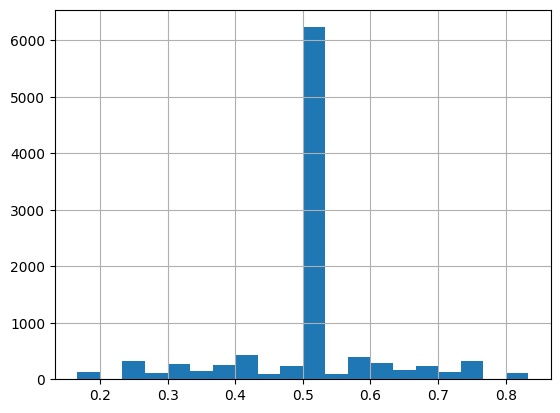

In [102]:
event_popularity["prob_1"].hist(bins=20)

In [103]:
bets = bets.drop(
    columns=["participant_1", "participant_2", "prob_1"],
    errors="ignore"
)

bets = bets.merge(
    event_popularity[
        ["event_id", "participant_1", "participant_2", "prob_1"]
    ],
    on="event_id",
    how="left"
)

random_values = np.random.random(len(bets))

bets["selection"] = np.where(
    random_values < bets["prob_1"],
    bets["participant_1"],
    bets["participant_2"]
)

In [104]:
bets["selection"].value_counts().head(10)

,count
selection,
Barcelona,28164
Liverpool,25648
América,23080
Real Betis,21850
Toluca,21725
Real Madrid,21102
Mazatlán FC,21035
Manchester United,20648
Tijuana,20063


In [105]:
participants[["participant_name", "sport", "competition", "popularity_score"]].sort_values("popularity_score",
    ascending=False).head(30)

,participant_name,sport,competition,popularity_score
53,Real Madrid,Football,LaLiga,181000000.0
85,Real Madrid,Football,Champions League,181000000.0
39,Atlético de Madrid,Football,LaLiga,179000000.0
62,Barcelona,Football,Champions League,148300000.0
40,Barcelona,Football,LaLiga,148300000.0
80,Paris Saint-Germain,Football,Champions League,67300000.0
33,Manchester United,Football,Premier League,66100000.0
32,Manchester City,Football,Premier League,56900000.0
76,Manchester City,Football,Champions League,56900000.0
75,Liverpool,Football,Champions League,48200000.0


In [106]:
event_participants = pd.concat([
    events[["event_id", "participants"]]
    .explode("participants")
    .rename(columns={"participants": "participant_name"})
])

event_participants["participant_name"].value_counts().head(30)

,count
participant_name,
Alexander Zverev,379
Carlos Alcaraz,364
Daniil Medvedev,359
Novak Djokovic,359
Frances Tiafoe,345
Taylor Fritz,344
Ben Shelton,342
Iga Swiatek,330
Jessica Pegula,329


In [107]:
event_participants.merge(
    participants[
        ["participant_name", "sport", "competition"]
    ],
    on="participant_name",
    how="left",
    indicator=True
)["_merge"].value_counts()

,count
_merge,
both,21996
left_only,0
right_only,0


In [108]:
bet_amount_parameters = {
    "Recreational": (5.0, 0.6),
    "Occasional": (5.5, 0.7),
    "High Value": (6.5, 0.8),
    "Seasonal": (5.9, 0.8)
}

In [109]:
def generate_bet_amount(segment, n):
    mu, sigma = bet_amount_parameters[segment]

    amounts = np.random.lognormal(
        mean=mu,
        sigma=sigma,
        size=n
    )

    return np.round(amounts, 2)

In [110]:
bets["bet_amount"] = 0.0

for segment in bet_amount_parameters:

    mask = bets["segment_client"] == segment

    bets.loc[mask, "bet_amount"] = generate_bet_amount(
        segment,
        mask.sum()
    )

In [111]:
bet_amount_limits = {
    "Recreational": (50, 500),
    "Occasional": (75, 800),
    "High Value": (300, 3000),
    "Seasonal": (100, 1500)
}

for segment, (min_amount, max_amount) in bet_amount_limits.items():

    mask = bets["segment_client"] == segment

    bets.loc[mask, "bet_amount"] = (
        bets.loc[mask, "bet_amount"]
        .clip(min_amount, max_amount)
    )

In [112]:
bets.groupby("segment_client")["bet_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
segment_client,,,,,,,,
High Value,471897.0,894.512161,673.648339,300.0,388.510,666.89,1142.8400,3000.0
Occasional,237684.0,299.486797,193.172643,75.0,153.060,245.33,391.8800,800.0
Recreational,166532.0,174.708926,103.455761,50.0,98.790,148.12,221.9825,500.0
Seasonal,321251.0,478.832522,360.861882,100.0,213.365,364.97,627.6400,1500.0


In [113]:
strength_dict = participants.set_index(
    "participant_name"
)["strength_score"].to_dict()

event_strength = events[
    ["event_id", "participants", "sport"]
].copy()

event_strength["participant_1"] = event_strength["participants"].apply(
    lambda x: x[0]
)

event_strength["participant_2"] = event_strength["participants"].apply(
    lambda x: x[1]
)

event_strength["strength_1"] = (
    event_strength["participant_1"].map(strength_dict)
)

event_strength["strength_2"] = (
    event_strength["participant_2"].map(strength_dict)
)

In [114]:
home_advantage_dict = participants.set_index(
    "participant_name"
)["home_advantage"].to_dict()

event_strength["home_advantage"] = (
    event_strength["participant_1"].map(home_advantage_dict)
)

event_strength["effective_strength_1"] = (
    event_strength["strength_1"] +
    event_strength["home_advantage"]
)

In [115]:
event_strength["effective_strength_1"] = event_strength["strength_1"]
event_strength["effective_strength_2"] = event_strength["strength_2"]

mask_home_1 = ~event_strength["sport"].eq("Baseball")

event_strength.loc[mask_home_1, "effective_strength_1"] += (
    event_strength.loc[mask_home_1, "participant_1"]
    .map(home_advantage_dict)
)

event_strength.loc[~mask_home_1, "effective_strength_2"] += (
    event_strength.loc[~mask_home_1, "participant_2"]
    .map(home_advantage_dict)
)

In [116]:
event_strength["p_1"] = (
    event_strength["effective_strength_1"] /
    (
        event_strength["effective_strength_1"] +
        event_strength["effective_strength_2"]
    )
)

In [117]:
event_strength["p_2"] = 1 - event_strength["p_1"]

In [118]:
bets = bets.merge(
    event_strength[
        ["event_id", "participant_1", "participant_2", "p_1", "p_2"]
    ],
    on="event_id",
    how="left"
)

In [119]:
bets.columns

Index(['user_id', 'placement_date', 'residence_country', 'competition',
       'event_id', 'event_date', 'segment_client', 'bet_type', 'market',
       'participants', 'participant_1_x', 'participant_2_x', 'prob_1',
       'selection', 'bet_amount', 'participant_1_y', 'participant_2_y', 'p_1',
       'p_2'],
      dtype='object')

In [120]:
(bets["participant_1_x"] == bets["participant_1_y"]).all()

np.True_

In [121]:
(bets["participant_2_x"] == bets["participant_2_y"]).all()

np.True_

In [122]:
bets = bets.rename(columns={
    "participant_1_x": "participant_1",
    "participant_2_x": "participant_2"
})

In [123]:
bets["selection_probability"] = np.where(
    bets["selection"] == bets["participant_1"],
    bets["p_1"],
    bets["p_2"]
)

In [124]:
bets = bets.drop(columns=["participant_1_y", "participant_2_y"])

In [125]:
bets["selection_probability"].describe()

,selection_probability
count,1.197364e+06
mean,5.010192e-01
std,3.208673e-02
min,3.178808e-01
25%,4.901961e-01
50%,5.056406e-01
75%,5.098039e-01
max,6.821192e-01


In [126]:
margin = 0.05

event_strength["margin_p1"] = (event_strength["p_1"]*(1+margin))
event_strength["margin_p2"] = (event_strength["p_2"]*(1+margin))

In [127]:
event_strength["fee_1"] = (1/event_strength["margin_p1"])
event_strength["fee_2"] = (1/event_strength["margin_p2"])

In [128]:
bets = bets.merge(
    event_strength[["event_id", "fee_1", "fee_2"]],
    on="event_id",
    how="left"
)

In [129]:
bets['fee'] = np.where(
    bets['selection'] == bets['participant_1'],
    bets['fee_1'],
    bets['fee_2']
)

In [130]:
bets = bets.drop(columns=['fee_1', 'fee_2'])

In [131]:
bets['fee'].describe()

,fee
count,1.197364e+06
mean,1.908955e+00
std,1.283719e-01
min,1.396209e+00
25%,1.868132e+00
50%,1.883514e+00
75%,1.942857e+00
max,2.996032e+00


In [132]:
p_time = {
    "Pre-Match": 0.85,
    "Live": 0.15
}

bets["time_modality"] = np.random.choice(
    list(p_time.keys()),
    size=len(bets),
    p=list(p_time.values())
)

In [133]:
bets['time_modality'].value_counts(normalize=True)

,proportion
time_modality,
Pre-Match,0.849402
Live,0.150598


In [134]:
events.columns

Index(['event_id', 'event_date', 'sport', 'competition', 'participants',
       'home_team', 'away_team', 'home_strength', 'away_strength',
       'home_advantage', 'eff_home_strength', 'p', 'result'],
      dtype='object')

In [135]:
bets = bets.merge(events[['event_id', 'result']], on='event_id', how='left')

In [136]:
bets["result"].isna().sum()

np.int64(0)

In [137]:
bets['event_winner'] = np.where(
    bets['result'] == 'Home_WIN',
    bets['participant_1'],
    bets['participant_2']
)

In [138]:
bets['bet_status'] = np.where(
    bets['selection'] == bets['event_winner'],
    "Won", "Lost"

)

In [139]:
bets.columns

Index(['user_id', 'placement_date', 'residence_country', 'competition',
       'event_id', 'event_date', 'segment_client', 'bet_type', 'market',
       'participants', 'participant_1', 'participant_2', 'prob_1', 'selection',
       'bet_amount', 'p_1', 'p_2', 'selection_probability', 'fee',
       'time_modality', 'result', 'event_winner', 'bet_status'],
      dtype='object')

In [140]:
bets['bet_status'].value_counts()

,count
bet_status,
Won,599105
Lost,598259


In [141]:
(
    bets["selection"] == bets["event_winner"]
).value_counts()

,count
True,599105
False,598259


In [142]:
bets[["selection", "event_winner"]].head(20)

,selection,event_winner
0,AEK Atenas,AEK Atenas
1,Roma,AEK Atenas
2,Roma,AEK Atenas
3,AEK Atenas,AEK Atenas
4,Aston Villa,Chelsea
5,Athletic Club,Celta de Vigo
6,Athletic Club,Celta de Vigo
7,Arsenal,Arsenal
8,Celta de Vigo,Celta de Vigo
9,Arsenal,Arsenal


In [143]:
bets.columns.tolist()

['user_id',
 'placement_date',
 'residence_country',
 'competition',
 'event_id',
 'event_date',
 'segment_client',
 'bet_type',
 'market',
 'participants',
 'participant_1',
 'participant_2',
 'prob_1',
 'selection',
 'bet_amount',
 'p_1',
 'p_2',
 'selection_probability',
 'fee',
 'time_modality',
 'result',
 'event_winner',
 'bet_status']

In [144]:
bets["result"].value_counts()

,count
result,
Home WIN,449095
Away WIN,445404
Draw,302865


In [145]:
bets["event_winner"].value_counts(dropna=False)

,count
event_winner,
Espanyol,24600
Liverpool,21931
Guadalajara,21588
América,21265
Real Betis,20594
...,...
ASVEL Villeurbanne,152
Paris Basketball,126
Valencia Basket,122


In [146]:
bets[
    ["selection", "event_winner", "bet_status"]
].head(20)

,selection,event_winner,bet_status
0,AEK Atenas,AEK Atenas,Won
1,Roma,AEK Atenas,Lost
2,Roma,AEK Atenas,Lost
3,AEK Atenas,AEK Atenas,Won
4,Aston Villa,Chelsea,Lost
5,Athletic Club,Celta de Vigo,Lost
6,Athletic Club,Celta de Vigo,Lost
7,Arsenal,Arsenal,Won
8,Celta de Vigo,Celta de Vigo,Won
9,Arsenal,Arsenal,Won


In [147]:
bets["bet_status"] = bets["event_winner"]

In [148]:
bets["bet_status"].value_counts()

,count
bet_status,
Espanyol,24600
Liverpool,21931
Guadalajara,21588
América,21265
Real Betis,20594
...,...
ASVEL Villeurbanne,152
Paris Basketball,126
Valencia Basket,122


In [149]:
bets.loc[
    bets["result"] == "Draw",
    ["result", "selection", "event_winner"]
].head(20)

,result,selection,event_winner
4,Draw,Aston Villa,Chelsea
7,Draw,Arsenal,Arsenal
9,Draw,Arsenal,Arsenal
13,Draw,Arsenal,Arsenal
14,Draw,Arsenal,Arsenal
35,Draw,Mazatlán FC,Mazatlán FC
37,Draw,Mazatlán FC,Mazatlán FC
41,Draw,Monterrey,Mazatlán FC
42,Draw,Mazatlán FC,Mazatlán FC
46,Draw,Mazatlán FC,Mazatlán FC


In [150]:
bets["result"].value_counts()

,count
result,
Home WIN,449095
Away WIN,445404
Draw,302865


In [151]:
pd.crosstab(
    bets["competition"],
    bets["result"]
)

result,Away WIN,Draw,Home WIN
competition,,,
ATP Tour,15232,0,18087
American_League,7487,0,8884
Champions League,90237,75782,99557
EuroLeague,1726,0,1654
LaLiga,97780,89106,86428
Liga MX,114288,80460,110200
NBA,22563,0,24282
National_League,4261,0,4402
Premier League,85368,57517,88852


In [152]:
bets["event_winner"] = np.select(
    [
        bets["result"].eq("Draw"),
        bets["result"].eq("Home WIN") & ~bets["competition"].isin(
            ["American_League", "National_League"]
        ),
        bets["result"].eq("Away WIN") & ~bets["competition"].isin(
            ["American_League", "National_League"]
        ),
        bets["result"].eq("Home WIN") & bets["competition"].isin(
            ["American_League", "National_League"]
        ),
        bets["result"].eq("Away WIN") & bets["competition"].isin(
            ["American_League", "National_League"]
        )
    ],
    [
        "Draw",
        bets["participant_1"],
        bets["participant_2"],
        bets["participant_2"],
        bets["participant_1"]
    ],
    default=None
)

In [153]:
bets["bet_status"] = np.where(
    bets["selection"] == bets["event_winner"],
    "Won",
    "Lost"
)

In [154]:
bets["event_winner"].value_counts()

,count
event_winner,
Draw,302865
FC Juárez,20756
América,18722
Mazatlán FC,17990
Manchester City,17828
...,...
Žalgiris Kaunas,125
Crvena Zvezda,123
Valencia Basket,118


In [155]:
bets["bet_status"].value_counts()

,count
bet_status,
Lost,746532
Won,450832


In [156]:
pd.crosstab(
    bets["result"],
    bets["bet_status"]
)

bet_status,Lost,Won
result,,
Away WIN,220392,225012
Draw,302865,0
Home WIN,223275,225820


## 3.6 Calculate bet returns


In [157]:
bets["return_amount"] = np.where(
    bets["bet_status"] == "Won",
    bets["bet_amount"] * bets["fee"],
    0
).round(2)

In [158]:
bets[[
    "bet_amount",
    "fee",
    "bet_status",
    "return_amount"
]].head(10)

,bet_amount,fee,bet_status,return_amount
0,142.79,1.942857,Lost,0.00
1,75.00,1.868132,Won,140.11
2,119.64,1.868132,Won,223.50
3,128.68,1.942857,Lost,0.00
4,322.47,1.868132,Lost,0.00
5,803.15,2.310686,Won,1855.83
6,1684.93,2.310686,Won,3893.34
7,136.47,1.942857,Lost,0.00
8,127.63,1.620147,Lost,0.00
9,533.50,1.942857,Lost,0.00


In [159]:
bets["return_amount"].describe()

,return_amount
count,1.197364e+06
mean,4.027626e+02
std,8.248560e+02
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,5.259500e+02
max,8.957800e+03


In [160]:
bets.groupby("bet_status")["return_amount"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
bet_status,,,,
Lost,746532,0.000000,0.00,0.0
Won,450832,1069.696611,72.74,8957.8


In [161]:
(bets.loc[bets["bet_status"] == "Lost", "return_amount"] != 0).sum()

np.int64(0)

In [162]:
(bets.loc[bets["bet_status"] == "Won", "return_amount"] <= 0).sum()

np.int64(0)

In [163]:
print("CUSTOMERS:", customers.shape)
print("EVENTS:", events.shape)
print("PARTICIPANTS:", participants.shape)
print("BETS:", bets.shape)
print("CUSTOMERS:", customers.columns.tolist())
print("EVENTS:", events.columns.tolist())
print("PARTICIPANTS:", participants.columns.tolist())
print("BETS:", bets.columns.tolist())

CUSTOMERS: (10000, 10)
EVENTS: (10000, 13)
PARTICIPANTS: (193, 10)
BETS: (1197364, 24)
CUSTOMERS: ['user_id', 'register_date', 'age', 'residence_country', 'payment_method', 'segment_client', 'active_days', 'annual_bets', 'n_bets', 'betting_dates']
EVENTS: ['event_id', 'event_date', 'sport', 'competition', 'participants', 'home_team', 'away_team', 'home_strength', 'away_strength', 'home_advantage', 'eff_home_strength', 'p', 'result']
PARTICIPANTS: ['participant_id', 'participant_name', 'sport', 'competition', 'popularity_score', 'strength_score', 'home_advantage', 'popularity_weight', 'popularity_log', 'popularity_normalized']
BETS: ['user_id', 'placement_date', 'residence_country', 'competition', 'event_id', 'event_date', 'segment_client', 'bet_type', 'market', 'participants', 'participant_1', 'participant_2', 'prob_1', 'selection', 'bet_amount', 'p_1', 'p_2', 'selection_probability', 'fee', 'time_modality', 'result', 'event_winner', 'bet_status', 'return_amount']


In [164]:
for name, df in {
    "customers": customers,
    "events": events,
    "participants": participants,
    "bets": bets
}.items():

    print(f"\n--- {name.upper()} ---")
    print("Nulos:", df.isna().sum().sum())

    # Determine columns to exclude from duplicate check
    exclude_cols = []
    if name == "customers":
        exclude_cols.append("betting_dates")
    elif name in ["events", "bets"]:
        exclude_cols.append("participants")

    # Get the subset of columns to check for duplicates
    # If exclude_cols is empty, all columns will be considered
    subset_cols = [col for col in df.columns if col not in exclude_cols]

    # Check for duplicates on the subset of columns
    print("Filas duplicadas:", df.duplicated(subset=subset_cols).sum())


--- CUSTOMERS ---
Nulos: 0
Filas duplicadas: 0

--- EVENTS ---
Nulos: 0
Filas duplicadas: 0

--- PARTICIPANTS ---
Nulos: 0
Filas duplicadas: 0

--- BETS ---
Nulos: 0
Filas duplicadas: 367


In [165]:
for name, df in {
    "customers": customers,
    "events": events,
    "participants": participants,
    "bets": bets
}.items():

    print(f"\n--- {name.upper()} ---")
    print(df.isna().sum()[df.isna().sum() > 0])


--- CUSTOMERS ---
Series([], dtype: int64)

--- EVENTS ---
Series([], dtype: int64)

--- PARTICIPANTS ---
Series([], dtype: int64)

--- BETS ---
Series([], dtype: int64)


In [166]:
print("Customer IDs duplicados:",
      customers["user_id"].duplicated().sum())

print("Event IDs duplicados:",
      events["event_id"].duplicated().sum())

print("Participant IDs duplicados:",
      participants["participant_id"].duplicated().sum())

Customer IDs duplicados: 0
Event IDs duplicados: 0
Participant IDs duplicados: 0


## 4. Dataset integrity checks


In [167]:
invalid_users = (
    ~bets["user_id"].isin(customers["user_id"])
).sum()

print("Bets with missing user:", invalid_users)

Bets with missing user: 0


In [168]:
invalid_events = (
    ~bets["event_id"].isin(events["event_id"])
).sum()

print("Bets with missing event:", invalid_events)

Bets with missing event: 0


In [169]:
bets_dates = bets.merge(
    customers[["user_id", "register_date"]],
    left_on="user_id",
    right_on="user_id",
    how="left"
)

print(
    "Bets placed before registration:",
    (bets_dates["placement_date"] < bets_dates["register_date"]).sum()
)

Bets placed before registration: 0


In [170]:
print(
    "Bets after project end date:",
    (bets["placement_date"] > pd.Timestamp("2025-12-30")).sum()
)

Bets after project end date: 0


In [171]:
events.columns

Index(['event_id', 'event_date', 'sport', 'competition', 'participants',
       'home_team', 'away_team', 'home_strength', 'away_strength',
       'home_advantage', 'eff_home_strength', 'p', 'result'],
      dtype='object')

In [172]:
event_check = bets.merge(
    events[["event_id", "event_date"]],
    on="event_id",
    how="left"
)

print(
    "Bets placed after event date:",
    (bets["placement_date"] > event_check["event_date_x"]).sum()
)

Bets placed after event date: 0


In [173]:
for col in [
    "bet_type",
    "market",
    "time_modality",
    "result",
    "bet_status"
]:
    print(f"\n{col}:")
    print(bets[col].value_counts())


bet_type:
bet_type
Parlay    552672
Single    473316
System    171376
Name: count, dtype: int64

market:
market
Match Winner    1197364
Name: count, dtype: int64

time_modality:
time_modality
Pre-Match    1017043
Live          180321
Name: count, dtype: int64

result:
result
Home WIN    449095
Away WIN    445404
Draw        302865
Name: count, dtype: int64

bet_status:
bet_status
Lost    746532
Won     450832
Name: count, dtype: int64


In [174]:
print(
    "Amounts <= 0:",
    (bets["bet_amount"] <= 0).sum()
)

print(
    "Odds <= 1:",
    (bets["fee"] <= 1).sum()
)

print(
    "Negative returns:",
    (bets["return_amount"] < 0).sum()
)

Amounts <= 0: 0
Odds <= 1: 0
Negative returns: 0


In [175]:
print(
    "Lost con return_amount != 0:",
    (
        (bets["bet_status"] == "Lost") &
        (bets["return_amount"] != 0)
    ).sum()
)

print(
    "Won con return_amount <= 0:",
    (
        (bets["bet_status"] == "Won") &
        (bets["return_amount"] <= 0)
    ).sum()
)

Lost con return_amount != 0: 0
Won con return_amount <= 0: 0


In [176]:
# ¿La selección siempre pertenece a los participants del evento?
invalid_selection = (
    ~(
        (bets["selection"] == bets["participant_1"]) |
        (bets["selection"] == bets["participant_2"])
    )
).sum()

print("Invalid selections:", invalid_selection)

Invalid selections: 0


In [177]:
# ¿El winner del evento es consistente con el result?
print(
    bets.groupby(["result", "event_winner"])
    .size()
    .unstack(fill_value=0)
)

event_winner  AEK Atenas  ASVEL Villeurbanne  Alexander Zverev  América  \
result                                                                    
Away WIN            1104                 102              1673     4944   
Draw                   0                   0                 0        0   
Home WIN            3256                  63              2415    13778   

event_winner  Anadolu Efes  Arizona Diamondbacks  Arsenal  Aryna Sabalenka  \
result                                                                       
Away WIN                88                   281     3827              728   
Draw                     0                     0        0                0   
Home WIN                94                   247     4510              934   

event_winner  Aston Villa  Athletic Club  ...  Utah Jazz  Valencia  \
result                                    ...                        
Away WIN             5288           2139  ...        404      7443   
Draw                   

In [178]:
bets_per_user = bets.groupby("user_id").size()

print(bets_per_user.describe())
print("\nUsers with 0 bets:",
      (customers["user_id"].isin(bets_per_user.index) == False).sum())

count    9919.000000
mean      120.714185
std       186.880184
min         1.000000
25%        22.000000
50%        45.000000
75%       127.000000
max      1154.000000
dtype: float64

Users with 0 bets: 81


In [179]:
bets.head()

,user_id,placement_date,residence_country,competition,event_id,event_date,segment_client,bet_type,market,participants,...,bet_amount,p_1,p_2,selection_probability,fee,time_modality,result,event_winner,bet_status,return_amount
0,U006194,2024-01-01,Brazil,Champions League,E002134,2024-01-01,Recreational,Single,Match Winner,"[Roma, AEK Atenas]",...,142.79,0.509804,0.490196,0.490196,1.942857,Pre-Match,Home WIN,Roma,Lost,0.00
1,U003557,2024-01-01,Brazil,Champions League,E002134,2024-01-01,Occasional,Single,Match Winner,"[Roma, AEK Atenas]",...,75.00,0.509804,0.490196,0.509804,1.868132,Pre-Match,Home WIN,Roma,Won,140.11
2,U001138,2024-01-01,Mexico,Champions League,E002134,2024-01-01,Recreational,Single,Match Winner,"[Roma, AEK Atenas]",...,119.64,0.509804,0.490196,0.509804,1.868132,Pre-Match,Home WIN,Roma,Won,223.50
3,U006567,2024-01-01,Mexico,Champions League,E002134,2024-01-01,Recreational,Parlay,Match Winner,"[Roma, AEK Atenas]",...,128.68,0.509804,0.490196,0.490196,1.942857,Pre-Match,Home WIN,Roma,Lost,0.00
4,U009694,2024-01-01,Argentina,Premier League,E003500,2024-01-01,Seasonal,System,Match Winner,"[Aston Villa, Chelsea]",...,322.47,0.509804,0.490196,0.509804,1.868132,Pre-Match,Draw,Draw,Lost,0.00


In [180]:
bets.columns

Index(['user_id', 'placement_date', 'residence_country', 'competition',
       'event_id', 'event_date', 'segment_client', 'bet_type', 'market',
       'participants', 'participant_1', 'participant_2', 'prob_1', 'selection',
       'bet_amount', 'p_1', 'p_2', 'selection_probability', 'fee',
       'time_modality', 'result', 'event_winner', 'bet_status',
       'return_amount'],
      dtype='object')

In [181]:
bets.rename(columns={'segment_client':'customer_segment',
                     'fee':'odds'})

,user_id,placement_date,residence_country,competition,event_id,event_date,customer_segment,bet_type,market,participants,...,bet_amount,p_1,p_2,selection_probability,odds,time_modality,result,event_winner,bet_status,return_amount
0,U006194,2024-01-01,Brazil,Champions League,E002134,2024-01-01,Recreational,Single,Match Winner,"[Roma, AEK Atenas]",...,142.79,0.509804,0.490196,0.490196,1.942857,Pre-Match,Home WIN,Roma,Lost,0.00
1,U003557,2024-01-01,Brazil,Champions League,E002134,2024-01-01,Occasional,Single,Match Winner,"[Roma, AEK Atenas]",...,75.00,0.509804,0.490196,0.509804,1.868132,Pre-Match,Home WIN,Roma,Won,140.11
2,U001138,2024-01-01,Mexico,Champions League,E002134,2024-01-01,Recreational,Single,Match Winner,"[Roma, AEK Atenas]",...,119.64,0.509804,0.490196,0.509804,1.868132,Pre-Match,Home WIN,Roma,Won,223.50
3,U006567,2024-01-01,Mexico,Champions League,E002134,2024-01-01,Recreational,Parlay,Match Winner,"[Roma, AEK Atenas]",...,128.68,0.509804,0.490196,0.490196,1.942857,Pre-Match,Home WIN,Roma,Lost,0.00
4,U009694,2024-01-01,Argentina,Premier League,E003500,2024-01-01,Seasonal,System,Match Winner,"[Aston Villa, Chelsea]",...,322.47,0.509804,0.490196,0.509804,1.868132,Pre-Match,Draw,Draw,Lost,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197359,U007156,2025-12-30,Argentina,Champions League,E004638,2025-12-31,High Value,Single,Match Winner,"[Fenerbahçe, Racing de Lens]",...,307.31,0.509804,0.490196,0.509804,1.868132,Pre-Match,Away WIN,Racing de Lens,Lost,0.00
1197360,U007155,2025-12-30,Mexico,WTA Tour,E002819,2025-12-31,High Value,Parlay,Match Winner,"[Renata Zarazua, Iga Swiatek]",...,606.07,0.469880,0.530120,0.469880,2.026862,Pre-Match,Away WIN,Iga Swiatek,Lost,0.00
1197361,U002077,2025-12-30,Brazil,Premier League,E002545,2025-12-30,Seasonal,Parlay,Match Winner,"[Nottingham Forest, Brighton & Hove Albion]",...,193.13,0.509804,0.490196,0.509804,1.868132,Pre-Match,Home WIN,Nottingham Forest,Won,360.79
1197362,U002666,2025-12-30,Mexico,Premier League,E002545,2025-12-30,High Value,Parlay,Match Winner,"[Nottingham Forest, Brighton & Hove Albion]",...,702.46,0.509804,0.490196,0.509804,1.868132,Pre-Match,Home WIN,Nottingham Forest,Won,1312.29


## Conclusion

The generated dataset is validated for referential integrity, date consistency, valid categorical values, and betting-return logic. It is now ready for exploratory data analysis and churn definition.
